### Инжиниринг численных признаков

#### Цель работы

Ознакомиться с основными приемами работы с численными атрибутами в датасетах для машинного обучения.

#### Содержание работы

1. Загрузить прилагающийся к работе датасет PRSA_Data
1. Выведите на экран основную информацию о датасете. Идентифицируйте значения вне разумного диапазона
1. Постройте визуализацию распределения каждого численного атрибута.
1. Исходя из распределения атрибутов по необходимости примените бинаризацию численных признаков.
1. Постройте совместное распределение каждого признака вместе с целевой переменной. Сделайте вывод о необходимости проведения группировки данных.
1. Удалите или ограничьте экстремальные значения атрибутов. 
1. Избавьтесь от пропущенных значений в датасете.
1. При необходимости округлите излишне точные значения атрибутов.
1. Рассмотрите возможность преобразования шкалы атрибута к логарифмической.

#### Методические указания

##### Первоначальное знакомство с данными

В данной работе мы поработаем с датасетом, содержащим информацию о разных численных показателях качества воздуха. Как всегда в первую очередь загрузим данные и выведем первые строки:### Инжиниринг численных признаков

#### Цель работы

Ознакомиться с основными приемами работы с численными атрибутами в датасетах для машинного обучения.

#### Содержание работы

1. Загрузить прилагающийся к работе датасет PRSA_Data
1. Выведите на экран основную информацию о датасете. Идентифицируйте значения вне разумного диапазона
1. Постройте визуализацию распределения каждого численного атрибута.
1. Исходя из распределения атрибутов по необходимости примените бинаризацию численных признаков.
1. Постройте совместное распределение каждого признака вместе с целевой переменной. Сделайте вывод о необходимости проведения группировки данных.
1. Удалите или ограничьте экстремальные значения атрибутов. 
1. Избавьтесь от пропущенных значений в датасете.
1. При необходимости округлите излишне точные значения атрибутов.
1. Рассмотрите возможность преобразования шкалы атрибута к логарифмической.

#### Методические указания

##### Первоначальное знакомство с данными

В данной работе мы поработаем с датасетом, содержащим информацию о разных численных показателях качества воздуха. Как всегда в первую очередь загрузим данные и выведем первые строки:

In [278]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [279]:
prsa_data = pd.read_csv("data/PRSA_Data.csv")
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,-1.0,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,-1.0,-1.000000,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,-1.0,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


Мы видим несколько атрибутов, характеризующих количество примесей различных газов при измерении качества воздуха. Последняя категориальная переменная в этом датасете - целевая, она обозначает класс чистоты воздуха

Для первоначального исследования количества значений выведем основную информацию о столбцах датасета:

In [280]:
prsa_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  35064 non-null  int64  
 1   No          35064 non-null  int64  
 2   SO2         35064 non-null  float64
 3   NO2         35064 non-null  float64
 4   CO          35064 non-null  float64
 5   O3          35064 non-null  float64
 6   PRES        35064 non-null  float64
 7   RAIN        35064 non-null  float64
 8   wd          35064 non-null  str    
 9   WSPM        35064 non-null  float64
 10  AQI Label   35064 non-null  str    
dtypes: float64(7), int64(2), str(2)
memory usage: 3.6 MB


Здесь мы видим, что на первый взгляд все значения заполнены, имеются две переменные с текстовым содержимым и семь - с численным

Так как большая часть атрибутов датасета выражена численно, информативным будет посмотреть основную численную статистику по данным:

In [281]:
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,17531.500000,17532.500000,18.058734,63.236861,1251.121692,45.876835,1010.520250,0.067653,1.500217
std,10122.249256,10122.249256,22.558126,39.109232,1269.033556,54.730861,26.289217,0.896833,1.105382
min,0.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,8765.750000,8766.750000,4.000000,34.000000,500.000000,2.397428,1002.500000,0.000000,0.800000
50%,17531.500000,17532.500000,10.000000,58.000000,900.000000,27.356346,1010.800000,0.000000,1.200000
75%,26297.250000,26298.250000,22.276800,87.000000,1500.000000,69.548316,1019.400000,0.000000,2.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,72.500000,11.200000


При внимательном рассмотрении нас должно смутить, что минимальное значение по многим столбцам, означающим концентрацию определенных газов, является значение -1

Исследование других статистик не дает нам пока никакой значимой очевидной информации, за исключением того, что разные столбцы имеют разные максимальные значения, то есть они измеряются по разным количественным шкалам. Это может навести нас на мысль о необходимости использования нормализации.

##### Идентификация ошибочных значений

Первым этапом анализа данных должно быть устранение явных ошибок в данных - значений атрибутов вне разумного диапазона. На предыдущем этапе мы уже обнаружили эту проблему. Значение концентрации газа в воздухе просто по смыслу не может быть отрицательным. При этом во всем датасете во всех колонках присутствует только одно отрицательное значение (убедитесь в этом самостоятельно): -1. Скорее всего, так в датасете обозначаются неизвестные значения. 

Такие "специальные значения" в численных атрибутах надо исправлять. Заменим их на np.nan, чтобы они явно отображались как пропуски и мы смогли в дальнейшем корректно с ними работать:

In [282]:
prsa_data[prsa_data == -1] = np.nan
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,NaN,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,NaN,NaN,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,NaN,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


Для проверки корректности замены выведем шапку датасета. Убедимся, что в данных появились пропуски

Самостоятельно повторите вывод статистики и убедитесь, что все численные столбцы принимаю неотрицательные значения.

In [283]:
numeric_cols = ['SO2', 'NO2', 'CO', 'O3', 'PRES', 'RAIN', 'WSPM']
for col in numeric_cols:
    prsa_data.loc[prsa_data[col] < 0, col] = np.nan
prsa_data[numeric_cols].min()

SO2       0.285600
NO2       1.642400
CO      100.000000
O3        0.016389
PRES    985.900000
RAIN      0.000000
WSPM      0.000000
dtype: float64

##### Визуализация распределения атрибутов

После того, как мы вычистили явные ошибки в данных, можно познакомиться с эмпирическим распределением каждого признака. Для этого можно использовать разные средства визуализации, например, гистограмму:

<Axes: xlabel='SO2', ylabel='Count'>

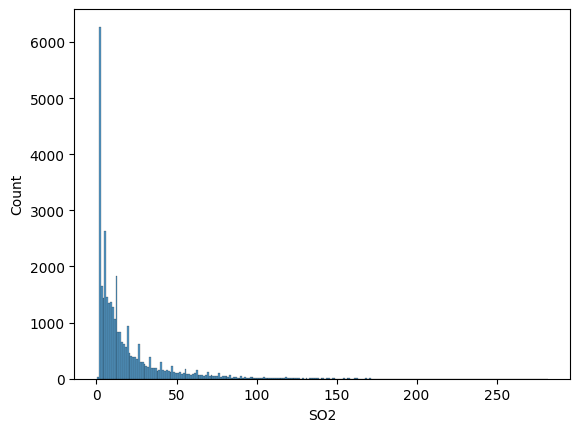

In [284]:
sns.histplot(prsa_data.SO2)

Здесь мы видим, какие значения концентрации SO2 присутствуют в датасете

Налицо явная зависимость - чем меньше значение, тем оно вероятнее. Очень большие концентрации встречаются крайне редко. Плюс, на графике можно заметить определенные пики через равные промежутки значений. Это может свидетельствовать о попытках заполнения пропущенных значений или об округлении некоторых значений.

Кроме гистограммы можно построить, например, график ядерной оценки плотности распределения:

<Axes: xlabel='NO2', ylabel='Density'>

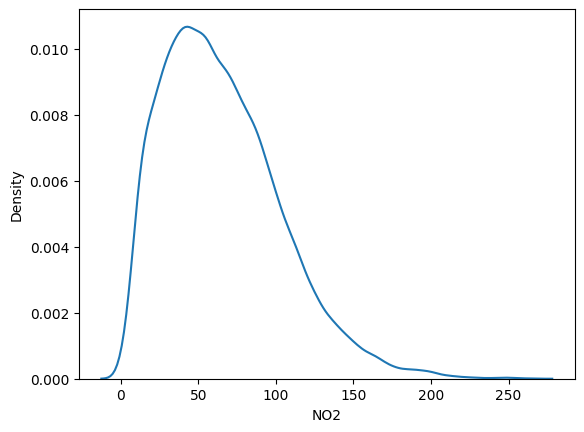

In [285]:
sns.kdeplot(prsa_data.NO2)

Но обратите внимание, что оценка плотности подразумевает некоторое усреднение. Поэтому не удивляйтесь тому, что график немного заходит на отрицательную область, хотя мы специально устраняли это не предыдущем этапе

Здесь мы видим уже другое распределение - более распространены значения, близкие к 50.

В дальнейшем будем пользоваться гистограммами. Вот распределение значений концентрации CO:

<Axes: xlabel='CO', ylabel='Count'>

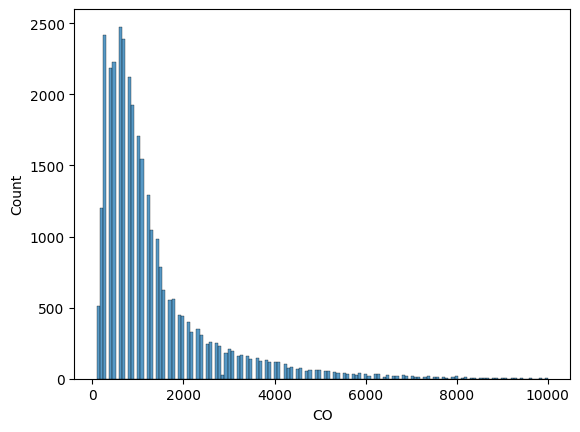

In [286]:
sns.histplot(prsa_data.CO)

Здесь видно достаточно гладкое распределение с модой в районе 1000.

Вот более смещенное распределение - O3. На гистограмме явно видно, что нулевая концентрация встречается гораздо чаще ненулевых значений. В дальнейшем это может быть кандидат на бинаризацию:

<Axes: xlabel='O3', ylabel='Count'>

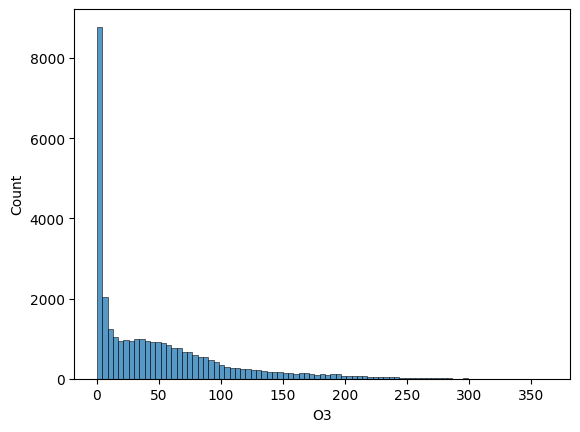

In [287]:
sns.histplot(prsa_data.O3)

Распределение значения давления отличается от всех предыдущих. Видно, что есть некоторый диапазон условно равновероятных, "нормальных" значений, а частота значений давления вне этого диапазона быстро спадает:

<Axes: xlabel='PRES', ylabel='Count'>

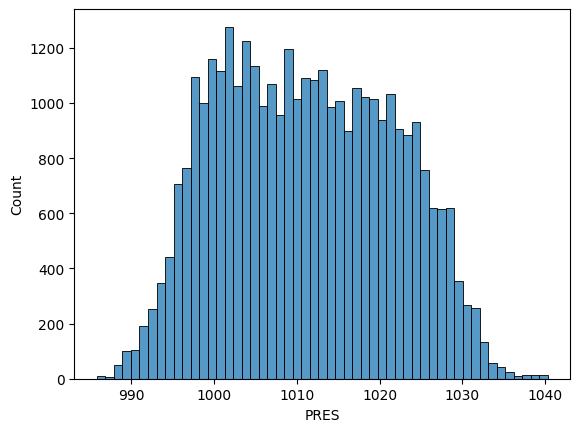

In [288]:
sns.histplot(prsa_data.PRES)

Такие атрибуты тоже можно категоризовывать при необходимости.

Распределение количества осадков тоже особенное:

<Axes: xlabel='RAIN', ylabel='Count'>

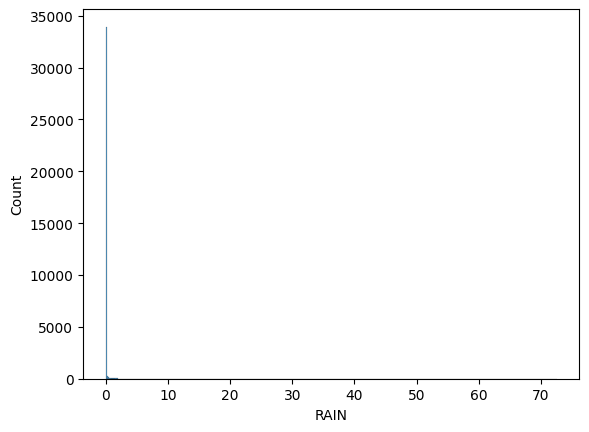

In [289]:
sns.histplot(prsa_data.RAIN)

Мы видим, что отсутствие осадков - самое распространенное значение. Ненулевые значения тут встречаются в подавляющем меньшинстве точек данных:

<Axes: xlabel='RAIN', ylabel='Count'>

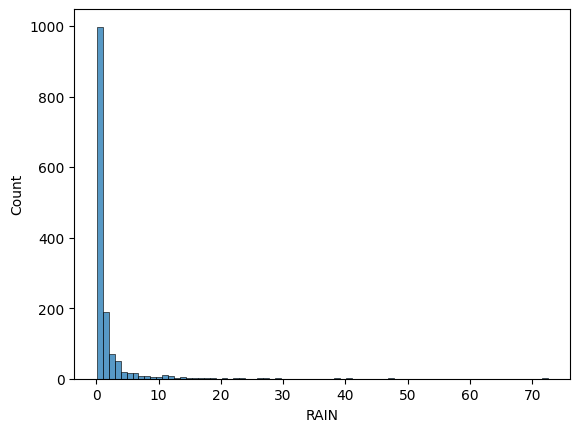

In [290]:
sns.histplot(prsa_data.RAIN[prsa_data.RAIN > 0])

<Axes: xlabel='WSPM', ylabel='Count'>

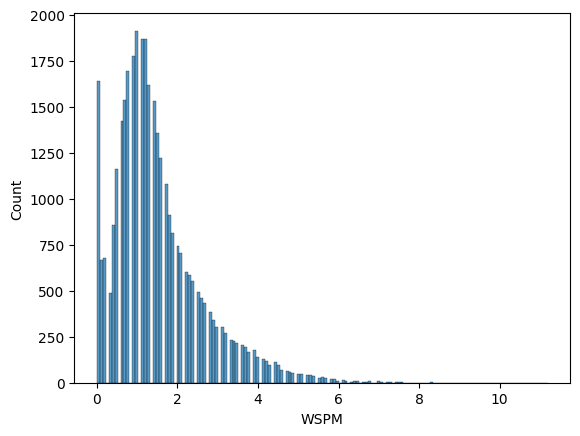

In [291]:
sns.histplot(prsa_data.WSPM)

##### Бинаризация атрибутов

Такие распределения, как в атрибуте "количество осадков" могут повредить эффективности модели, так как относительное численной значение при таком распределении не несет, по сути, статистической значимости по сравнению с информацией о том, были ли вообще осадки или нет. То есть этот атрибут из численного можно превратить в категориальный. Ведь в нашем датасете всего 1436 точек из 35 000 имеют ненулевое значение:

In [292]:
prsa_data.RAIN[prsa_data.RAIN > 0]

267      0.1
268      0.4
269      0.1
270      0.9
271      0.9
        ... 
34891    0.2
34892    0.7
34893    0.9
34894    0.4
34895    0.2
Name: RAIN, Length: 1436, dtype: float64

Так важно ли будет для модели конкретное численное значение количества осадков при таком малом относительном объеме? Мы можем ввести в модель новый категориальный, а точнее, бинарный атрибут, кодирущий наличие либо отсутствие осадков в данном измерении:

In [293]:
is_rain = np.array(prsa_data.RAIN)
is_rain[is_rain > 0] = 1
prsa_data['IS_RAIN'] = is_rain
prsa_data.drop(['RAIN'], axis=1, inplace=True)
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,WSPM,IS_RAIN
count,35064.000000,35064.000000,34489.000000,33994.000000,33252.000000,32938.000000,35044.000000,35050.000000,35044.000000
mean,17531.500000,17532.500000,18.376481,65.258789,1319.353513,48.902003,1011.097536,1.501215,0.040977
std,10122.249256,10122.249256,22.609648,37.996088,1268.114331,55.116915,10.355247,1.104472,0.198240
min,0.000000,1.000000,0.285600,1.642400,100.000000,0.016389,985.900000,0.000000,0.000000
25%,8765.750000,8766.750000,4.000000,36.000000,500.000000,3.592269,1002.500000,0.800000,0.000000
50%,17531.500000,17532.500000,10.000000,60.000000,900.000000,31.968225,1010.800000,1.200000,0.000000
75%,26297.250000,26298.250000,23.000000,88.000000,1600.000000,72.910474,1019.400000,2.000000,0.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,11.200000,1.000000


Обратите внимание, что для воспроизводимости кода предпочтительнее такие преобразования не производить над существующей колонкой, а создавать новую. Старую всегда можно будет удалить. Либо исследовать относительную важности признаков и принять решение после этого. А вот как будет выглядеть датасет после преобразования


##### Визуализация связи атрибутов с целевой переменной

После первоначального преобразования данных нужно определить, как именно связаны различные атрибуты со значением целевой переменной. Так как мы исследуем численные атрибуты при категориальной целевой переменной, то воспользуемся визуализацией нескольких оценок плотности распределения для разных классов:

<Axes: xlabel='SO2', ylabel='Density'>

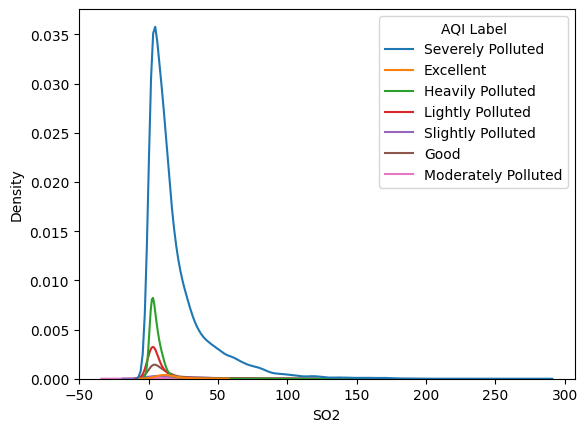

In [294]:
sns.kdeplot(data=prsa_data, x="SO2", hue="AQI Label")

Мы получим на графике несколько линий, каждая из которых соответствует распределению выбранного атрибута при разных значениях целевой переменной

Так как у нас наблюдается дисбаланс классов (это мы еще не исследовали, но из данного графика ясно видно, что всего объектов разных классов сильно разное количество), то нам не очень важен на таких графиках конкретный уровень каждой линии. Важно понять, есть ли участки на горизонтальной оси, на которых соотношение разных существенно отличается.

Например, на первом графике, явных изменений в форме разных линий нет. Можно предположить, что изолированно данный атрибут не сильно влияет на значение целевой переменной. Пойдем дальше и визуализируем второй атрибут:

<Axes: xlabel='NO2', ylabel='Density'>

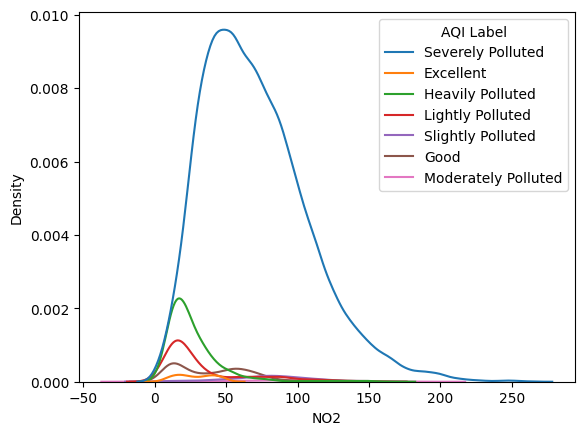

In [295]:
sns.kdeplot(data=prsa_data, x="NO2", hue="AQI Label")

Здесь уже видны различия между соотношениям разных классов. Но они не очень ярко выраженные. Перейдем к третьему атрибуту:

/tmp/ipykernel_6248/491964310.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")


<Axes: xlabel='CO', ylabel='Density'>

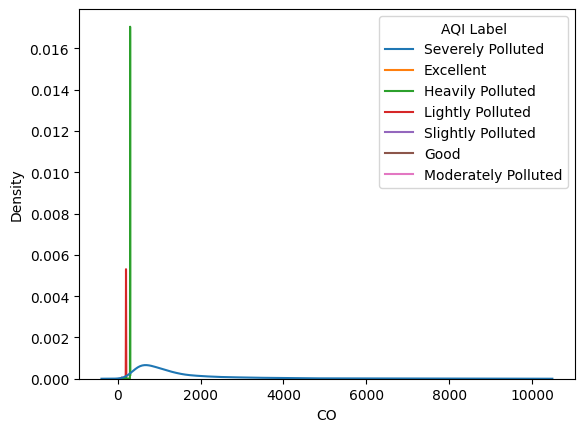

In [296]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")


Данный график очень смещен из-за того, что плотности некоторых классов сильно сконцентрированы, что искажает масштаб графика. В таких случаях помогает попробовать изобразить этот же график, но с логарифмическим масштабом вертикальной оси:

/tmp/ipykernel_6248/2756761127.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)


<Axes: xlabel='CO', ylabel='Density'>

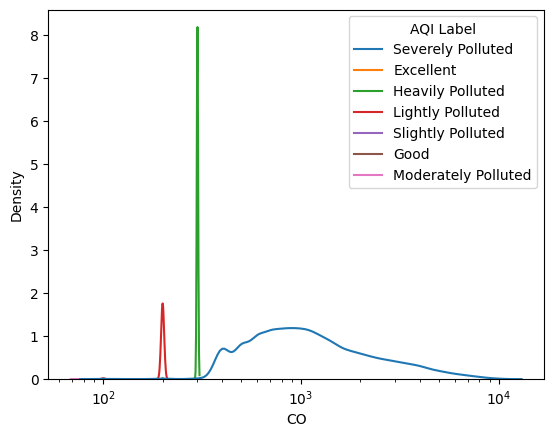

In [297]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)

Теперь мы четко видим те самые различия

На некоторых участках диапазона значений данного атрибута преобладает значение "Lightly polluted", на других - "Heavily polluted". Это значит, что данный атрибут очень важен для предсказания значения целевой переменной. В дальнейшем мы используем эту информацию для категоризации этого атрибута.

Следующие графики демонстрируют схожее поведение разных классов с поправкой на общую форму распределения разных атрибутов:

<Axes: xlabel='O3', ylabel='Density'>

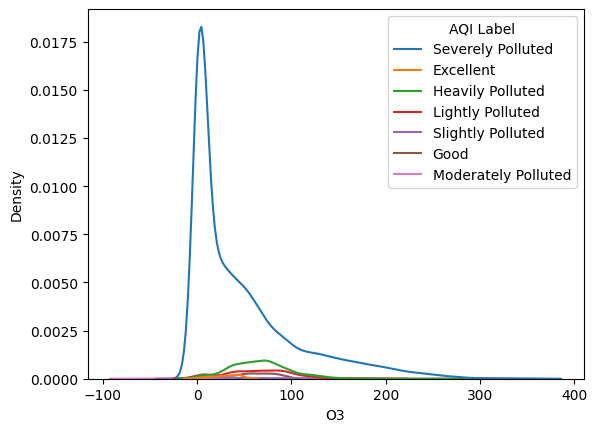

In [298]:
sns.kdeplot(data=prsa_data, x="O3", hue="AQI Label")

<Axes: xlabel='PRES', ylabel='Density'>

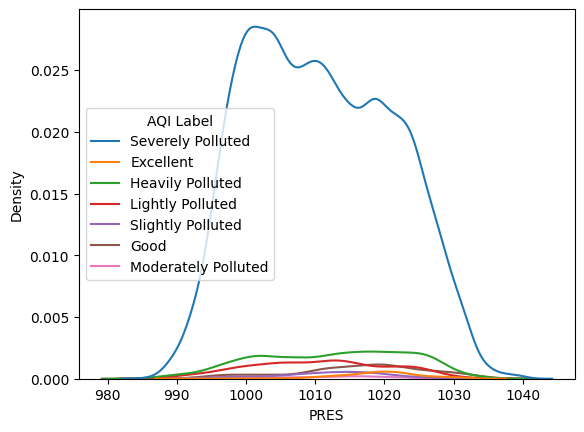

In [299]:
sns.kdeplot(data=prsa_data, x="PRES", hue="AQI Label")

<Axes: xlabel='WSPM', ylabel='Density'>

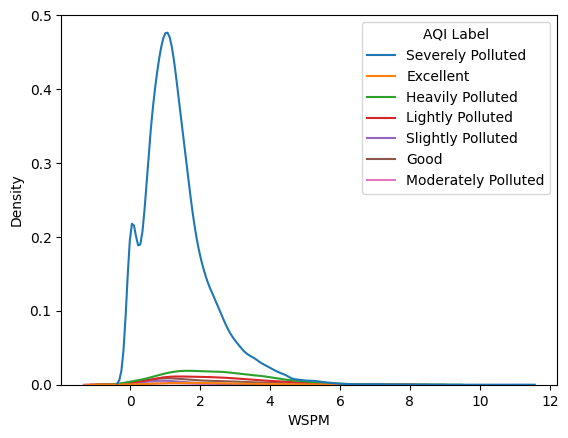

In [300]:
sns.kdeplot(data=prsa_data, x="WSPM", hue="AQI Label")

##### Группировка численных значений

В некоторых случаях бывает полезно объединить численные значения атрибутов на метку диапазона значений. То есть мы объединяем (группируем) объекты по значению данного атрибута и затем заменяем сам численный атрибут на ту группу, в которую попал объект. Этот прием называется дискретизация или группировка численных значений. Например, возьмем атрибут "CO". На предыдущем шаге мы уже выяснили, что объекты, находящиеся в различных диапазонах его значений будут иметь разное распределение целевой переменной. Условные границы этих диапазонов можно изобразить на графике:

/tmp/ipykernel_6248/491964310.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")


<Axes: xlabel='CO', ylabel='Density'>

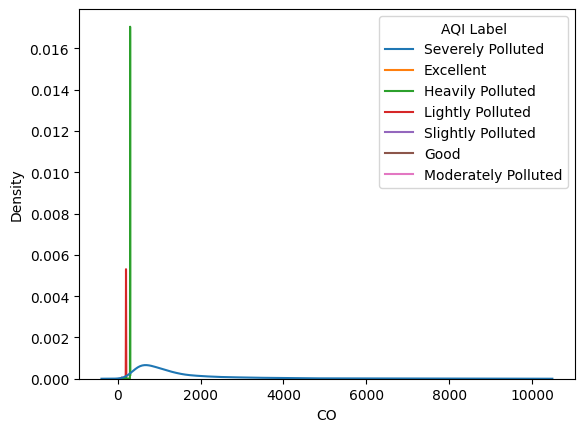

In [301]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")

В данном случае, для значения целевой переменной не так важно конкретное численной значение концентрации CO в воздухе. Достаточно информации, в какой диапазон попадает данное измерение. Поэтому попробуем добавить к датасету атрибут "Группа по CO":

In [302]:
bin_ranges = [0, 250, 320, 10000]
bin_names = [1, 2, 3]
prsa_data['CO_bin_custom_label'] = pd.cut(np.array(prsa_data['CO']), 
                                               bins=bin_ranges, labels=bin_names)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,NaN
4,4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


В данном примере, границы атрибутов мы определяли вручную, по графику выше. Можно их определять автоматически, через изменение долей распределения целевой переменной, либо брать в качестве границ квартили или процентили.

Здесь у нас возникает проблема. Так как в исходном столбце были пропущенные значения, в получившемся столбце тоже будут пропуски. Так как этот новый атрибут - категориальный, проще всего сразу заполнить пропущенные значения специальным названием класса. В данном случае, естественно будет присвоить этому классу метко "0", что будет означать - "значение неизвестно":

In [303]:
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].values.add_categories(0)
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].fillna(0).astype(int)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,0
4,4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


Обратите внимание, что мы можем не удалять сразу исходный столбец. Обычно все ненужные столбцы удаляются из датасета в самом конце, перед массовым преобразованием категориальных переменных. Либо решение о целесообразности удаления можно принято позже, по результатам дальнейшего анализа.

##### Удаление экстремальных значений

При анализе распределений особый интерес вызывают такие, у которых наблюдаются длинные "хвосты" - то есть очень редкие значения далеко от среднего или медианного значения. Это такие объекты, которых очень мало (может быть, даже один) и которые по значению данной характеристики сильно отличаются от основной массы объектов. Часто такие выбросы свидетельствуют о некорректных данных, либо о аномальных и непоказательных объектах. Объекты, которые нерелевантны решаемой задаче следует удалять из выборки. Но сами по себе длинные "хвосты" распределений могут повредить работе моделей. Поэтому зачастую датасеты с большими выбросами очищают от них автоматически.

Для этого можно удалить объекты, значения определенного атрибута у которых выше или ниже определенного порога или процентиля. Но в таком случае мы лишаемся определенного количества информации, которая была заключена в значении других атрибутов данного объекта. Альтернативный способ - клиппинг. Он заключается в том, что мы заменяем экстремальные значения атрибута граничным.

Возьмем для примера колонку "PRES" нашего датасета. В данном примере определим границы экстремальных значений опять же на глаз. И заменим все значения, находящиеся вне этих границ:

In [304]:
prsa_data.PRES[prsa_data.PRES <= 992] = 992
prsa_data.PRES[prsa_data.PRES >= 1034] = 1034

/tmp/ipykernel_6248/3964902396.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  prsa_data.PRES[prsa_data.PRES <= 992] = 992
/tmp/ipykernel_6248/3964902396.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_inde

Посмотрите, как это изменяет форму эмпирического распределения данного атрибута:

<Axes: xlabel='PRES', ylabel='Count'>

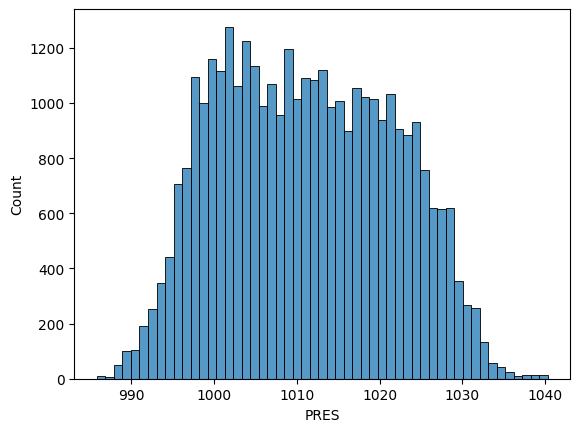

In [305]:
sns.histplot(prsa_data.PRES)

Поэкспериментируйте с клиппингом с разными значениями границ. Посмотрите, как они влияют на форму получившегося распределения. Поробуйте применить клиппинг к другим атрибутам этого датасета.

/tmp/ipykernel_6248/2742424692.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  prsa_data['PRES_clipped_1'][prsa_data['PRES_clipped_1'] < 1000] = 1000
/tmp/ipykernel_6248/2742424692.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Writ

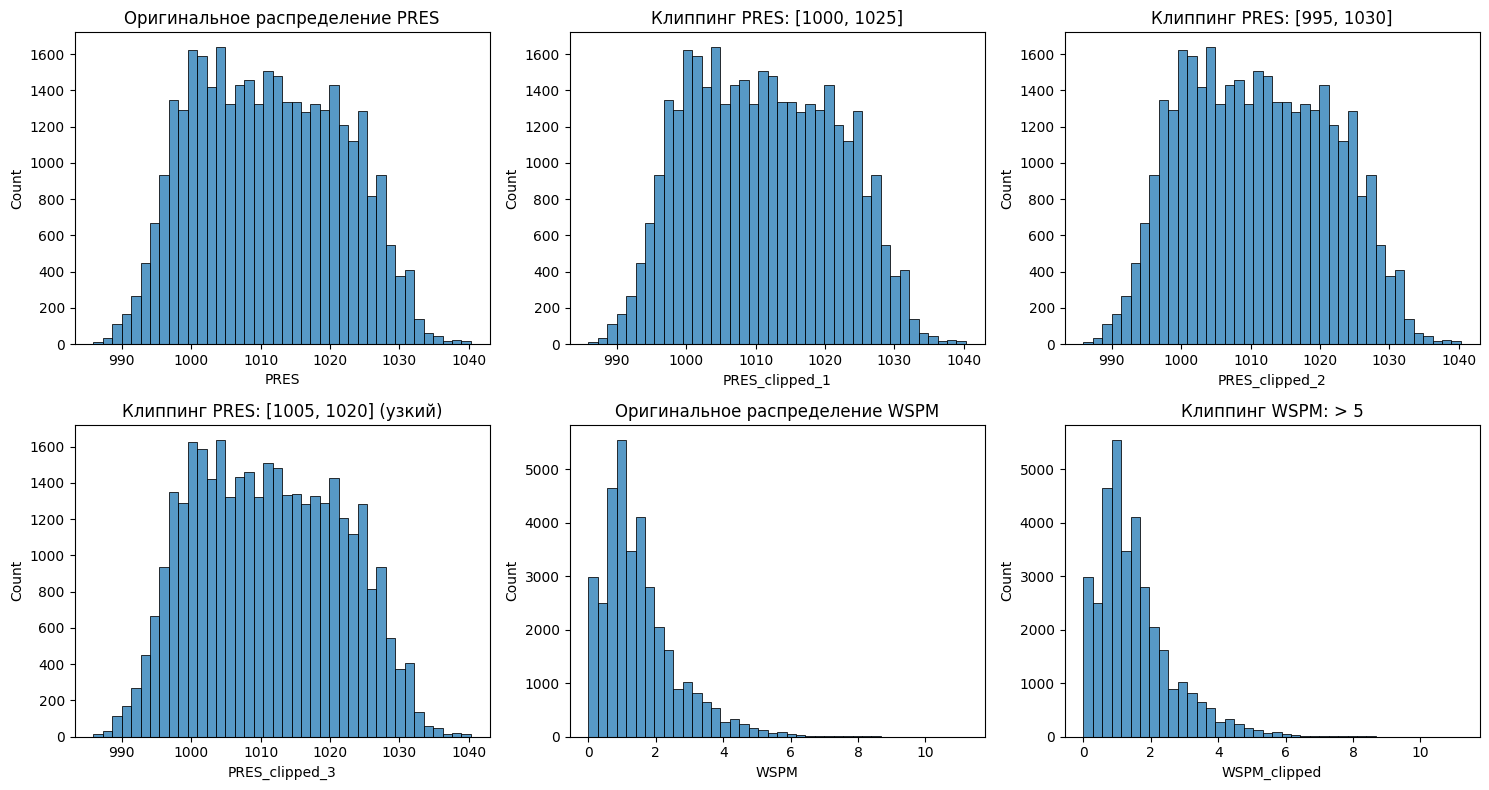

In [306]:
prsa_data_after_method_clip = prsa_data.copy()

# Клиппинг PRES с разными границами
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Оригинальное распределение
sns.histplot(prsa_data_original['PRES'].dropna(), ax=axes[0], bins=40)
axes[0].set_title('Оригинальное распределение PRES')

# Клиппинг с границами [1000, 1025]
prsa_data['PRES_clipped_1'] = prsa_data_original['PRES'].copy()
prsa_data['PRES_clipped_1'][prsa_data['PRES_clipped_1'] < 1000] = 1000
prsa_data['PRES_clipped_1'][prsa_data['PRES_clipped_1'] > 1025] = 1025
sns.histplot(prsa_data['PRES_clipped_1'].dropna(), ax=axes[1], bins=40)
axes[1].set_title('Клиппинг PRES: [1000, 1025]')

# Клиппинг с границами [995, 1030]
prsa_data['PRES_clipped_2'] = prsa_data_original['PRES'].copy()
prsa_data['PRES_clipped_2'][prsa_data['PRES_clipped_2'] < 995] = 995
prsa_data['PRES_clipped_2'][prsa_data['PRES_clipped_2'] > 1030] = 1030
sns.histplot(prsa_data['PRES_clipped_2'].dropna(), ax=axes[2], bins=40)
axes[2].set_title('Клиппинг PRES: [995, 1030]')

# Клиппинг с границами [1005, 1020] (узкий диапазон)
prsa_data['PRES_clipped_3'] = prsa_data_original['PRES'].copy()
prsa_data['PRES_clipped_3'][prsa_data['PRES_clipped_3'] < 1005] = 1005
prsa_data['PRES_clipped_3'][prsa_data['PRES_clipped_3'] > 1020] = 1020
sns.histplot(prsa_data['PRES_clipped_3'].dropna(), ax=axes[3], bins=40)
axes[3].set_title('Клиппинг PRES: [1005, 1020] (узкий)')

# Эксперимент с другим атрибутом: WSPM
sns.histplot(prsa_data_original['WSPM'].dropna(), ax=axes[4], bins=40)
axes[4].set_title('Оригинальное распределение WSPM')

prsa_data['WSPM_clipped'] = prsa_data_original['WSPM'].copy()
prsa_data['WSPM_clipped'][prsa_data['WSPM_clipped'] > 5] = 5
sns.histplot(prsa_data['WSPM_clipped'].dropna(), ax=axes[5], bins=40)
axes[5].set_title('Клиппинг WSPM: > 5')

plt.tight_layout()
plt.show()


prsa_data = prsa_data_after_method_clip.copy()

Клиппинг атмосферного давления с разными границами показывает, что сужение диапазона (особенно до [1005, 1020]) приводит к появлению ярко выраженных "пиков" на границах, где скапливаются все обрезанные значения. Это искажает реальное распределение, создавая ложное впечатление, что аномально много измерений имеет ровно граничные значения. Слишком широкие границы ([995, 1030]) почти не меняют форму распределения, а слишком узкие сильно деформируют его. Оптимальные границы (как в методичке: 992 и 1034) лишь незначительно убирают редкие выбросы, сохраняя естественную форму распределения.

Для скорости ветра клиппинг показывает, что большинство значений сосредоточено в диапазоне до 5 м/с, а более высокие скорости — редкие выбросы. Обрезание WSPM на уровне 5 м/с приводит к заметному пику на границе, но при этом удаляются физически возможные, хотя и редкие, сильные ветры. Вывод: клиппинг полезен для устранения явных аномалий, но требует осторожного подбора границ, чтобы не потерять значимую информацию и не внести искусственные артефакты в распределение.

##### Заполнение пропусков

Обязательной частью предварительной обработки данных является устранение отсутствующих значений. В первую очередь нужно позаботиться о том, чтобы все реально имеющиеся в данных пропуски отображались в датасете как np.nan или другое детектируемое значение. Это мы уже сделали. 

Теперь можно визуализировать пропущенные значения в данных:

<Axes: >

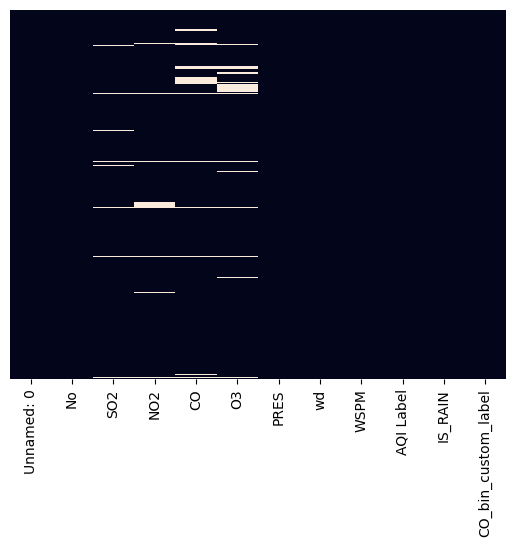

In [307]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

Данная диаграмма показывает графически как расположены пропуски в данных

Можно обратить внимание на то, что в датасете прослеживаются горизонтальные полосы. Это объекты, по которым неизвестны значения нескольких атрибутов. Можно вывести индексы объектов, у которых неизвестно значение более двух атрибутов:

In [308]:
undef = prsa_data.isnull().sum(axis=1)
undef[undef >= 2]

3        2
276      3
435      2
459      2
555      2
        ..
34880    4
34883    4
34885    4
35029    2
35030    2
Length: 893, dtype: int64

Здесь мы видим, что таких объектов всего 893

Так как такие незаполненные объекты составляют очень малый процент выборки, для простоты обработки их можно просто удалить:

In [309]:
prsa_data = prsa_data.drop(undef[undef >= 2].index, axis=0)

Повторим визуализацию пропусков. Теперь мы видим, что пропуски группируются по столбцам:

<Axes: >

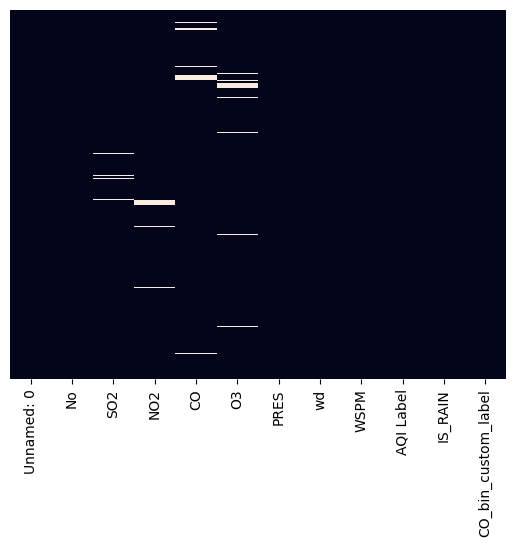

In [310]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

Выведем количество пропущенных значений для каждого атрибута:

In [311]:
prsa_data.isnull().sum()

Unnamed: 0                0
No                        0
SO2                     281
NO2                     702
CO                     1019
O3                     1310
PRES                      0
wd                        0
WSPM                      0
AQI Label                 0
IS_RAIN                   0
CO_bin_custom_label       0
dtype: int64

По столбцу SO2 пропущено всего 281 значение. Это менее одного процента выборки. Можно просто заменить пропуски на среднее значение. Но так как эмпирическое распределение этого признака имеет большую асимметрию, лучше использовать медиану:

In [312]:
prsa_data.SO2 = prsa_data.SO2.fillna(prsa_data.SO2.mean())

<Axes: xlabel='SO2', ylabel='Count'>

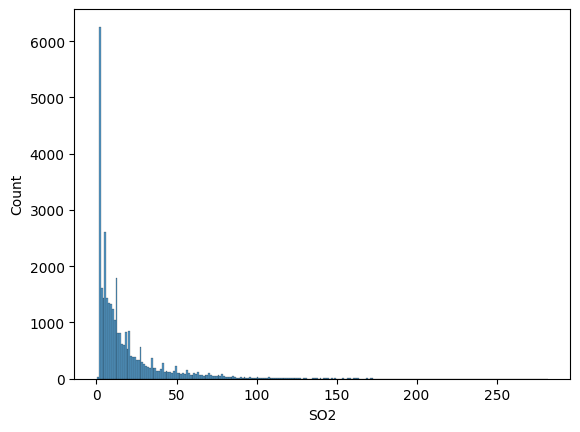

In [313]:
sns.histplot(prsa_data.SO2)

С другими столбцами, например, O3 искажение будет более существенным. Поэтому воспользуемся заполнением не средним, а случайным значением. Для этого сначала сформируем временную серию, содержащую все пропуски из данного столбца:

In [314]:
filler = prsa_data.O3[prsa_data.O3.isna()]

Нам важно, чтобы в этой серии сохранился исходный индекс - номера строк с пропусками исходного датасета. Это мы используем при заполнении этой серии данными. В этом примере не будем генерировать случайные значения их какого-то распределения, а просто семплируем их из существующих значений:

In [315]:
filler = prsa_data.O3[~prsa_data.O3.isna()].sample(n=len(filler)).set_axis(filler.index)

Теперь просто воспользуемся ей для заполнения пропусков в исходном датасете:

In [316]:
prsa_data.O3 = prsa_data.O3.fillna(filler)

Вот как выглядит распределение значений данного атрибута после заполнения пропусков

<Axes: xlabel='O3', ylabel='Count'>

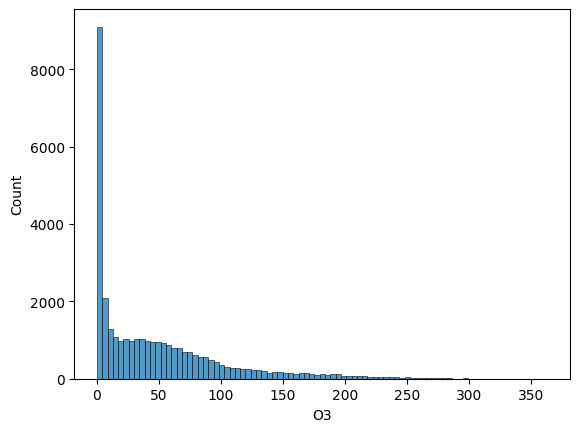

In [317]:
sns.histplot(prsa_data.O3)

Сравните его с распределением до заполнения.

Заполнение пропусков случайными значениями из существующих данных (семплирование) сохраняет общую форму исходного распределения, в отличие от заполнения средним или медианой, которые создавали бы искусственный пик в одной точке. Это хороший метод для асимметричных распределений с длинными хвостами.

##### Округление атрибутов

При визуальном осмотре датасета можно заметить, что все численные значения имеют один знак после запятой. Но столбец O3 записан с гораздо большей точностью - 5 знаков после запятой. Такая точность является избыточной, так как получается, что в этой колонке записаны 7 значащих цифр. От лишних данных можно избавиться, просто округлив данные значения:

In [318]:
prsa_data['O3'] = np.array(np.round((prsa_data['O3'])), dtype='int')
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.000000,28.0,400.0,52,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.000000,28.0,400.0,50,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,18.324655,19.0,400.0,55,1023.5,NNW,5.6,Severely Polluted,0.0,3
4,4,5,9.000000,NaN,300.0,54,1025.2,N,2.0,Heavily Polluted,0.0,2
5,5,6,8.000000,17.0,300.0,54,1025.6,N,3.7,Heavily Polluted,0.0,2


##### Логарифмирование атрибутов

Еще один прием, который не часто применяется, но иногда бывает полезен - кастомное решкалирование значений. В целом, решкалирование - это изменение шкалы измерения атрибута. Например, изменение граничных значений, масштабирование, нормализация. Но в определенных случаях, может быть полезно применить и другое преобразование данных. Опять обратим внимание на столбец SO2. Сейчас его значения очень сильно смещены. Малых значений очень много, а значит, что даже маленькие разницы между ними могут быть существенны для модели. А вот больших значений очень мало, и даже большие расстояния между ними могут быть не очень показательны.

Вообще, математические модели лучше всего работают с распределениями, похожими на равномерное или нормальное. Очень большой дисбаланс в распределении может быть вреден для эффективности.

Мы можем попробовать применить к атрибуту любую математическую функцию, чтобы преобразовать его к более равномерному распределению. Только эта функция должна быть непрерывная и монотонная. В данном случае, нам будет полезен логарифм:

In [319]:
prsa_data.SO2 = np.log(prsa_data.SO2)

Посмотрите, как после логарифмирования изменилось распределение этого признака:

<Axes: xlabel='SO2', ylabel='Count'>

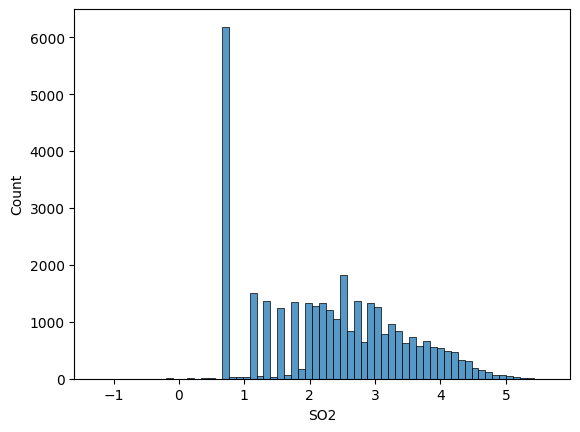

In [320]:
sns.histplot(prsa_data.SO2)

При таком равномерном распределении информации модели будет легче работать с этим признаком.

### Контрольные вопросы

**1. Как в датасете идентифицировать численные атрибуты?**

Численные атрибуты в датасете можно идентифицировать несколькими способами. Во-первых, с помощью метода info() — он выводит тип данных каждого столбца (dtype): численные атрибуты имеют типы int64, int32, float64, float32. Во-вторых, с помощью метода describe() — он по умолчанию выводит статистику только для численных столбцов (среднее, стандартное отклонение, минимум, квартили, максимум). В-третьих, можно использовать селекторы dtypes: df.select_dtypes(include=['int64', 'float64']) вернёт только численные колонки. Также визуально численные атрибуты отличаются тем, что их значения представляют собой числа, которые имеют математический смысл (их можно складывать, умножать, сравнивать по величине). В отличие от категориальных, где числа могут быть просто метками (например, 1, 2, 3 для обозначения классов обслуживания), численные атрибуты имеют единицы измерения и позволяют говорить о разнице между значениями.

**2. Какие основные виды непрерывных распределений часто встречаются на практике анализа данных?**

На практике анализа данных чаще всего встречаются следующие виды непрерывных распределений. Нормальное распределение (распределение Гаусса) — симметричное колоколообразное распределение, характерное для роста человека, погрешностей измерений, многих биологических и социальных показателей. Логнормальное распределение — когда логарифм случайной величины распределён нормально, часто встречается в экономике (доходы населения), в экологии (размеры особей). Экспоненциальное распределение — описывает время между случайными событиями (время ожидания, время безотказной работы), характеризуется быстрым убыванием частоты с ростом значения. Степенной распределение (распределение Парето) — "длинный хвост", когда малые значения встречаются очень часто, а большие — очень редко (распределение городов по населению, частоты слов, богатство населения). Равномерное распределение — все значения в диапазоне равновероятны, встречается реже, обычно в искусственных данных или при округлении. Распределение с несколькими модами (мультимодальное) — имеет несколько пиков, что свидетельствует о наличии разных групп объектов в выборке. В данном датасете мы наблюдали экспоненциальноподобные распределения для SO2 и CO, двухмодальное для O3, асимметричное с длинным хвостом для NO2, а также распределение PRES, близкое к нормальному с небольшим сдвигом.

**3. Какие типы графиков можно использовать для визуализации одномерного непрерывного распределения?**

Для визуализации одномерного непрерывного распределения можно использовать следующие типы графиков. Гистограмма (histogram) — самый распространённый и информативный вариант: ось X разбивается на интервалы (бины), высота столбцов показывает количество объектов в каждом интервале или плотность распределения. График ядерной оценки плотности (KDE — Kernel Density Estimation) — сглаженная версия гистограммы, особенно полезна для сравнения нескольких распределений на одном графике. Ящик с усами (boxplot) — показывает медиану, квартили, размах и выбросы, удобен для сравнения распределений по разным категориям. Диаграмма размаха (violin plot) — комбинирует boxplot и KDE, показывает и квартили, и форму распределения. Точечная диаграмма (strip plot) — каждая точка соответствует одному объекту, хорошо видна плотность, но при большом количестве данных точки сливаются. Q-Q-график — используется для проверки, соответствует ли распределение теоретическому (например, нормальному). На практике чаще всего используют гистограмму для первичного анализа и KDE для сравнения групп.

**4. Какие типы графиков можно использовать для визуализации совместного распределения: с другой непрерывной переменной? А с категориальной переменной?**

Для визуализации совместного распределения двух непрерывных переменных используются следующие графики. Диаграмма рассеяния (scatter plot) — каждый объект изображается точкой с координатами (значение первого признака, значение второго признака), позволяет увидеть форму связи (линейную, нелинейную) и наличие выбросов. Совместная гистограмма (jointplot) — комбинирует диаграмму рассеяния с гистограммами или KDE каждой переменной по краям. Тепловая карта двумерной гистограммы (hexbin) — поле разбивается на шестиугольники, цветом показывается количество точек в каждом, удобно при большом объёме данных. Линия регрессии с доверительным интервалом (regplot) — добавляет к scatter plot модель линейной зависимости. Матрица диаграмм рассеяния (pairplot) — для визуализации всех пар непрерывных переменных одновременно.

Для визуализации совместного распределения непрерывной и категориальной переменной используются следующие графики. Ящик с усами (boxplot) — по оси X откладываются категории, по оси Y — значения непрерывной переменной, позволяет сравнить медиану, разброс и выбросы в разных группах. Скрипичный график (violin plot) — аналогично boxplot, но показывает ещё и форму распределения в каждой категории. Столбчатая диаграмма средних (barplot с агрегацией) — отображает среднее значение непрерывной переменной для каждой категории, часто с доверительными интервалами. Совмещённые KDE — на одном графике строятся оценки плотности непрерывной переменной отдельно для каждой категории (использовалось в методичке). Swarm plot — точечная диаграмма, где точки разнесены, чтобы не сливаться, хорошо при небольшом количестве данных. В методичке для этой цели использовался график kdeplot с параметром hue, который показывает распределение численного атрибута (SO2, CO, O3) отдельно для каждого класса целевой переменной (AQI Label).

**5. Как выбрать метод борьбы с пропущенными значениями?**

Выбор метода борьбы с пропущенными значениями зависит от нескольких факторов: количества пропусков, типа данных признака, структуры пропусков и целей моделирования. Основные стратегии и их применение:

Удаление строк с пропусками (listwise deletion) применяется, когда пропусков мало (менее 5% от всех объектов) и они распределены случайно. В методичке именно так поступили с объектами, у которых было пропущено более двух атрибутов (884 строки из 35064). Удаление столбца целиком применяется, когда пропусков в столбце очень много (более 50-70%) и признак не является критически важным — в методичке так не делали, но это распространённый приём.

Заполнение константой (например, 0 или "unknown") применяется для категориальных признаков и для численных, когда ноль имеет смысл (например, количество осадков). Заполнение средним (mean) применяется для численных признаков с распределением, близким к нормальному, и когда нет сильных выбросов. Заполнение медианой (median) применяется для численных признаков с асимметричным распределением или наличием выбросов — в методичке так заполнили пропуски в столбце SO2 (использовали медиану, так как распределение асимметричное). Заполнение модой (mode) применяется для категориальных признаков.

Заполнение случайными значениями из существующих (random sampling) применяется, когда важно сохранить распределение признака — в методичке так заполнили пропуски в O3, взяв случайные значения из не пропущенных наблюдений. Заполнение предсказанными значениями (с помощью модели) применяется для важных признаков с большим количеством пропусков, когда есть другие признаки, позволяющие предсказать пропущенное значение. Интерполяция и экстраполяция применяются для временных рядов.

Общее правило: сначала нужно понять природу пропусков (случайные или систематические), затем оценить их долю. При малом количестве пропусков (до 5%) можно удалять строки. При среднем количестве (5-20%) — заполнять медианой или модой. При большом количестве (более 20%) — стоит рассмотреть удаление признака или использовать продвинутые методы (предсказание моделью, множественная импутация). Выбор метода обязательно должен проверяться на качество итоговой модели: разные способы заполнения могут давать разное влияние на точность.